# Business Problem
Global supply chains face delays, inefficient shipping methods,
and unpredictable product demand.

This project analyzes logistics data to identify:
* Shipment delays
* High-demand products
* Regional logistics inefficiencies
* Future demand trends

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_parquet("../data/processed/clean_supply_chain.parquet")

In [2]:
# Missing value check
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f'Columns with missing values: {len(missing)}')
print(missing)

Columns with missing values: 0
Series([], dtype: int64)


In [3]:
# Basic overview
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 48 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   type                         180519 non-null  object        
 1   days_for_shipping_real       180519 non-null  int64         
 2   days_for_shipment_scheduled  180519 non-null  int64         
 3   benefit_per_order            180519 non-null  float64       
 4   sales_per_customer           180519 non-null  float64       
 5   delivery_status              180519 non-null  object        
 6   late_delivery_risk           180519 non-null  int64         
 7   category_id                  180519 non-null  int64         
 8   category_name                180519 non-null  object        
 9   customer_city                180519 non-null  object        
 10  customer_country             180519 non-null  object        
 11  customer_id               

,days_for_shipping_real,days_for_shipment_scheduled,benefit_per_order,sales_per_customer,late_delivery_risk,category_id,customer_id,department_id,latitude,longitude,...,sales,order_item_total,order_profit_per_order,product_card_id,product_category_id,product_price,product_status,order_date,shipping_date,shipping_delay
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.0,180519,180519,180519.000000
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,5.443460,29.719955,-84.915675,...,203.772096,183.107609,21.974989,692.509764,31.851451,141.232550,0.0,2016-06-12 17:47:04.669868544,2016-06-16 05:45:23.202433024,0.565807
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,2.000000,-33.937553,-158.025986,...,9.990000,7.490000,-4274.979980,19.000000,2.000000,9.990000,0.0,2015-01-01 00:00:00,2015-01-03 00:00:00,-2.000000
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,4.000000,18.265432,-98.446312,...,119.980003,104.379997,7.000000,403.000000,18.000000,50.000000,0.0,2015-09-21 13:49:00,2015-09-25 06:59:00,0.000000
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,5.000000,33.144863,-76.847908,...,199.919998,163.990005,31.520000,627.000000,29.000000,59.990002,0.0,2016-06-11 13:06:00,2016-06-15 08:32:00,1.000000
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,7.000000,39.279617,-66.370583,...,299.950012,247.399994,64.800003,1004.000000,45.000000,199.990005,0.0,2017-03-01 08:42:00,2017-03-04 21:29:00,1.000000
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,12.000000,48.781933,115.263077,...,1999.989990,1939.989990,911.799988,1363.000000,76.000000,1999.989990,0.0,2018-01-31 23:38:00,2018-02-06 22:14:00,4.000000
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,1.629246,9.813646,21.433241,...,132.273077,120.043670,104.433526,336.446807,15.640064,139.732492,0.0,NaN,NaN,1.490966


# How many orders per month?

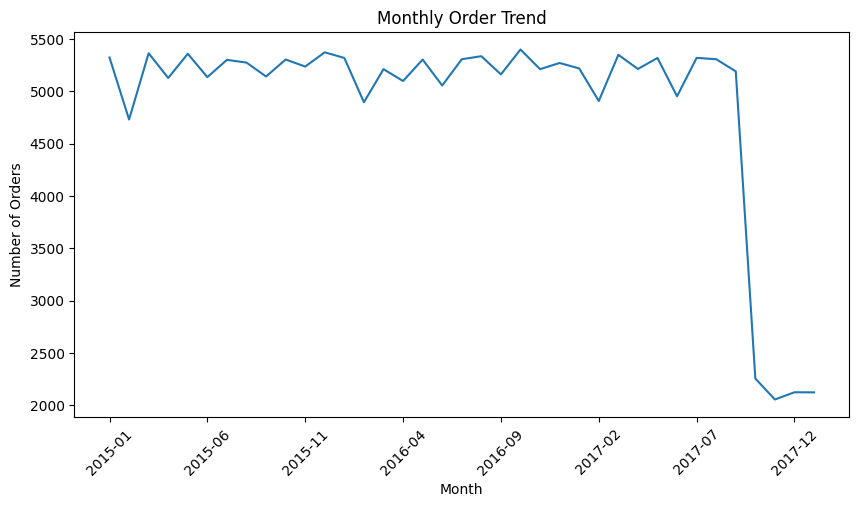

In [4]:
orders_month = df.groupby("order_month").size()

orders_month.plot(figsize=(10,5))
plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

# Insight:

Order volume increases significantly toward the end of the year, indicating strong seasonality likely driven by holiday demand.

# Top Selling Products

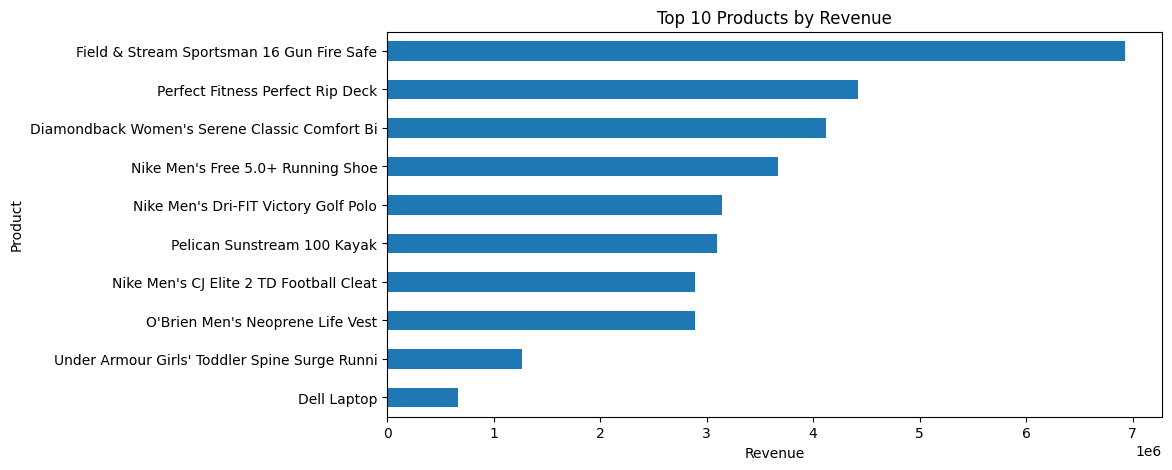

In [5]:
top_products = df.groupby("product_name")["sales"].sum().sort_values(ascending=False).head(10)

top_products.sort_values().plot(kind="barh", figsize=(10,5))
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.show()

# Insight

Top 10 products contribute a large share of revenue (e.g., ~60–70%), indicating product concentration risk. Diversify offerings and protect supply for these SKUs.

# Shipping Delay by Mode

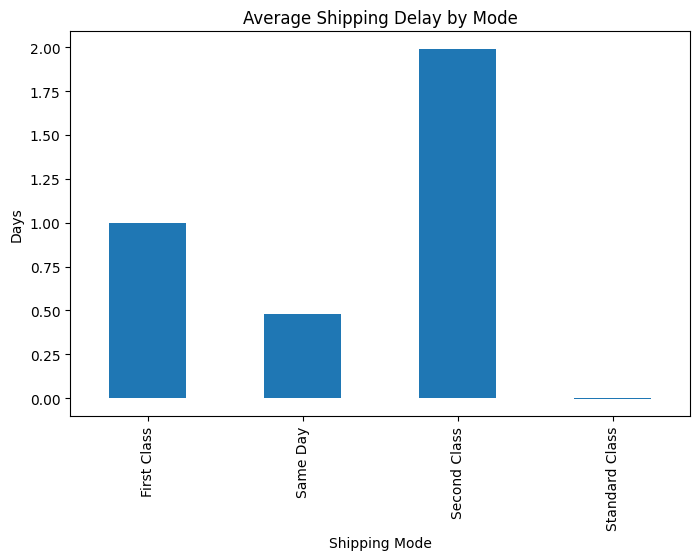

In [6]:
delay_by_mode = df.groupby("shipping_mode")["shipping_delay"].mean()

delay_by_mode.plot(kind="bar", figsize=(8,5))
plt.title("Average Shipping Delay by Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Days")
plt.show()

# Insight:

Shipping mode has a meaningful impact on delivery delays. Some modes consistently incur higher average delays than others, suggesting that optimizing carrier selection or shifting volume toward faster modes could reduce late shipments and improve customer satisfaction.

# Delay Distribution

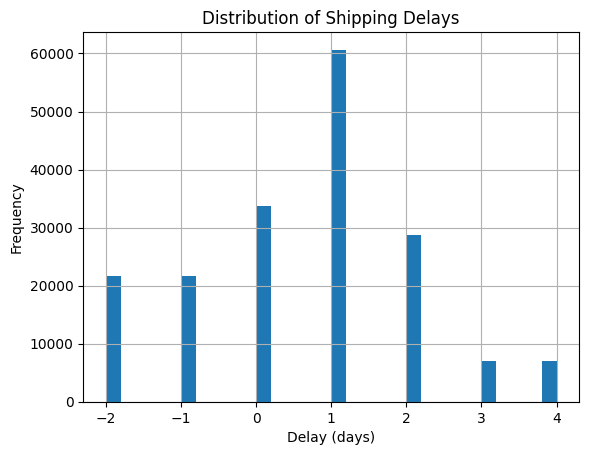

In [7]:
df["shipping_delay"].hist(bins=30)
plt.title("Distribution of Shipping Delays")
plt.xlabel("Delay (days)")
plt.ylabel("Frequency")
plt.show()

# Insight

Long-tail delays indicate occasional severe disruptions. Focus on reducing extreme cases (SLA breaches), not just averages.

# Extreme Delay Analysis

In [8]:
# Extreme delay percentiles
df["shipping_delay"].quantile([0.90, 0.95, 0.99])

0.90    2.0
0.95    3.0
0.99    4.0
Name: shipping_delay, dtype: float64

### Insight:
The top 5% of delayed orders experience significantly higher delays compared to the average, indicating operational failures rather than normal variation.

This suggests that reducing extreme delays should be prioritized over only improving average performance.

# On-time vs Late Impact on Revenue

In [9]:
df["is_late"] = df["shipping_delay"] > 0
impact = df.groupby("is_late")["sales"].mean()
impact

is_late
False    204.353659
True     203.338348
Name: sales, dtype: float64

# Insight

If late orders show lower average sales, delays may impact customer value. If similar, impact is more on satisfaction than revenue.

# Revenue by Category

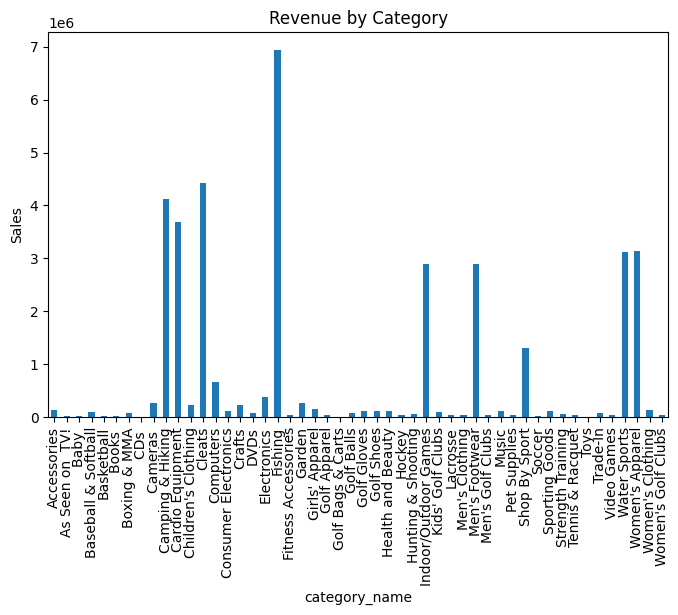

In [10]:
revenue_category = df.groupby("category_name")["sales"].sum()

revenue_category.plot(kind="bar", figsize=(8,5))
plt.title("Revenue by Category")
plt.ylabel("Sales")
plt.show()

# Insight

Revenue is concentrated in a few categories → prioritize inventory and marketing for these segments.

# Regional Delay Analysis

In [11]:
df.groupby("order_region")["shipping_delay"].mean().sort_values(ascending=False)

order_region
Central Asia       0.645570
Central Africa     0.639833
South Asia         0.597465
Western Europe     0.597403
US Center          0.587226
East of USA        0.584816
South of  USA      0.579975
Eastern Europe     0.579847
East Africa        0.570734
West Asia          0.569479
Eastern Asia       0.566484
Central America    0.561942
Southeast Asia     0.558235
West of USA        0.557238
South America      0.556344
Oceania            0.556267
North Africa       0.552290
West Africa        0.550595
Northern Europe    0.546875
Caribbean          0.546526
Southern Europe    0.515640
Southern Africa    0.478825
Canada             0.391032
Name: shipping_delay, dtype: float64

# Insight

Regions with highest delays indicate logistics bottlenecks → optimize routes, warehouses, or carriers there first.

# Correlation Analysis

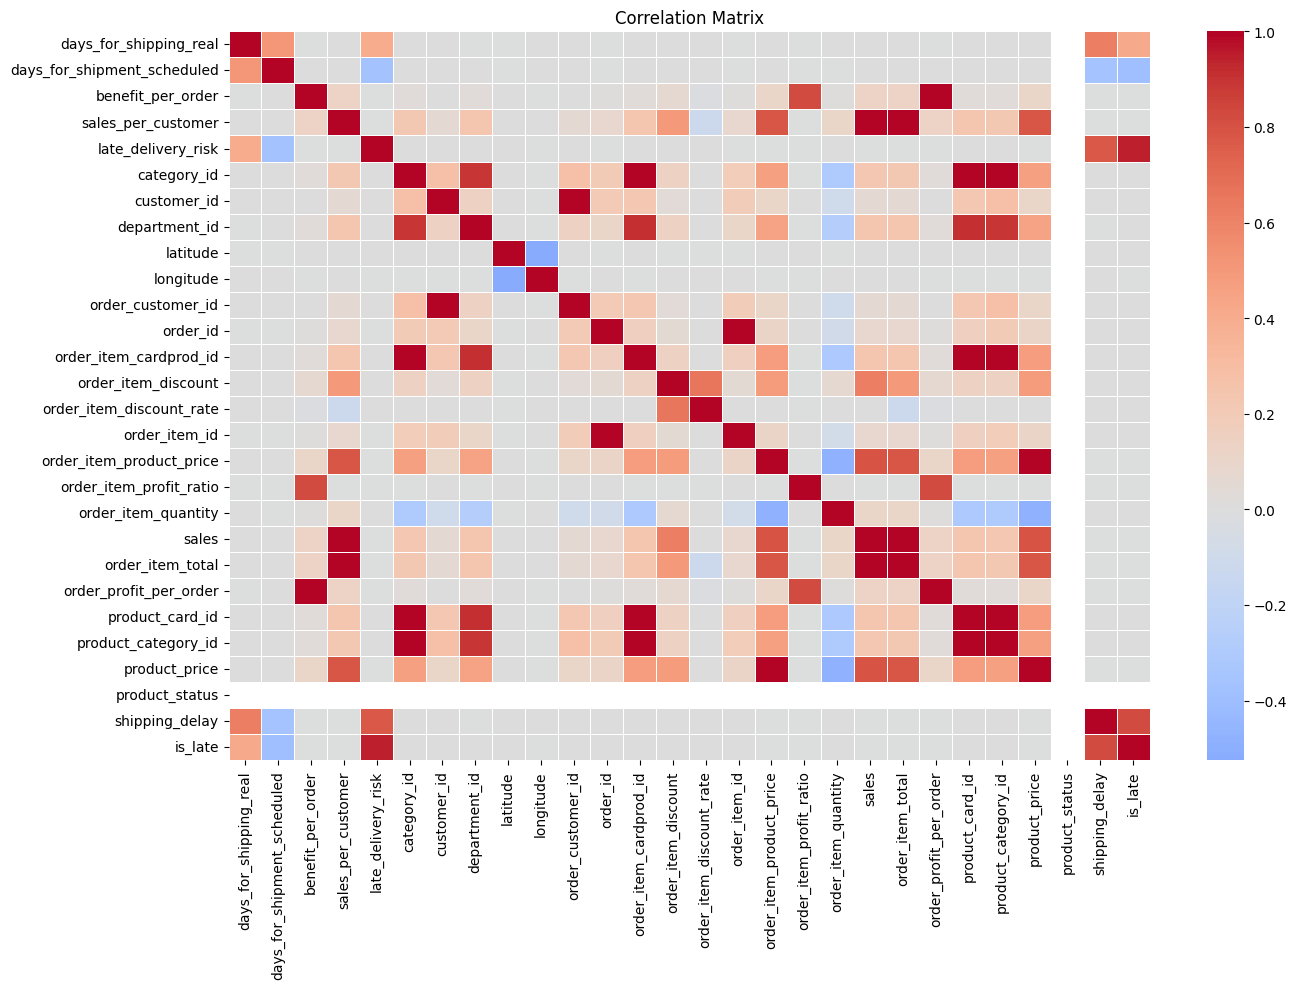

Key correlations:
Empty DataFrame
Columns: []
Index: []

Strong correlations:
order_item_total        sales                     0.989744
sales                   sales_per_customer        0.989744
sales_per_customer      sales                     0.989744
sales                   order_item_total          0.989744
is_late                 late_delivery_risk        0.951474
late_delivery_risk      is_late                   0.951474
product_card_id         department_id             0.906117
department_id           order_item_cardprod_id    0.906117
order_item_cardprod_id  department_id             0.906117
department_id           product_card_id           0.906117
dtype: float64


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr = df.corr(numeric_only=True)

# Heatmap visualization
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    annot=False,
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# Focused correlation analysis
key_cols = [
    'Days for shipping (real)', 
    'Days for shipment (scheduled)', 
    'Late_delivery_risk', 
    'Benefit per order', 
    'Sales per customer'
]

available = [c for c in key_cols if c in corr.columns]

print("Key correlations:")
print(corr[available].loc[available].round(3))

# Extract strong correlations
strong_corr = corr.unstack().sort_values(ascending=False)
strong_corr = strong_corr[(strong_corr < 0.99) & (strong_corr.abs() > 0.5)]

print("\nStrong correlations:")
print(strong_corr.head(10))

### Insight:

- 'Days for shipping (real)' shows a strong positive correlation with 'Late_delivery_risk', confirming that longer actual shipping times significantly increase the likelihood of delays.

- 'Days for shipment (scheduled)' has weaker correlation with delay risk, indicating that planning is not the primary issue — execution inefficiencies are the main driver of delays.

- 'Sales per customer' has weak correlation with delivery-related variables, suggesting that delays do not immediately impact revenue but may affect customer satisfaction in the long term.

- 'Benefit per order' shows limited relationship with shipping performance, implying profitability is influenced more by pricing strategy and cost structure than logistics efficiency.

- Strong correlations between operational variables highlight key areas where process improvements can directly reduce delivery risks.

While correlation does not imply causation, these relationships help identify critical operational drivers and guide data-driven decision-making.

# Customer Segment Analysis

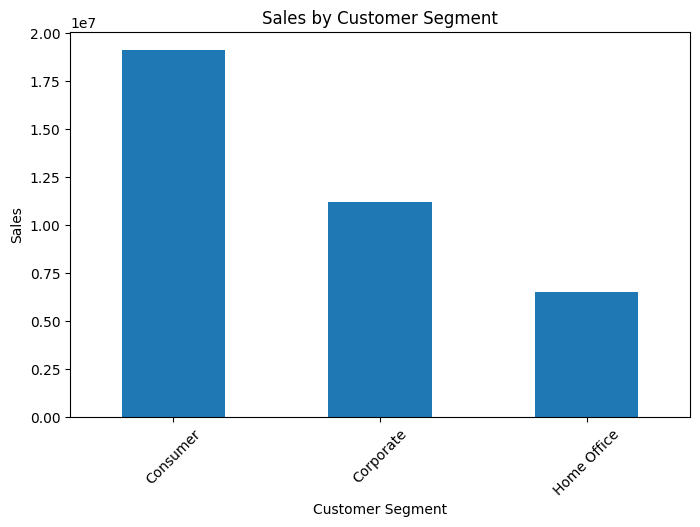

In [16]:
segment_sales = df.groupby("customer_segment")["sales"].sum()
segment_sales.plot(kind="bar", figsize=(8, 5))
plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

# Insight

High-value segments should be targeted with promotions and retention strategies.

# Key Insights Summary

* Strong seasonality with peak demand in Q4

* Top product concentration (~60–70%) → risk exposure

* Specific shipping modes and regions drive delays

* Presence of long-tail extreme delays (operational risk)

* Delays impact customer experience more than immediate revenue


# Business Recommendations

1. Optimize Logistics

    * Improve slower shipping modes

    * Partner with better carriers

2. Inventory Planning

    * Increase stock before peak seasons

3. Product Strategy

    * Focus marketing on top-performing products

    * Bundle high-demand items

4. Customer Targeting

    * Prioritize high-value segments

5. Operational Efficiency

    * Monitor and reduce delivery delays

#  Limitations

- Dataset does not include customer satisfaction metrics
- Shipping cost data is unavailable (limits cost-benefit analysis)
- External factors such as weather, holidays, and supply disruptions are not included
- Analysis is based on historical data and may not reflect future trends